# End-to-End WBTC/WETH MEV Arbitrage Notebook

This notebook is fully self-contained and no longer depends on the local `src/mev_dataset` package.

It runs the full workflow in one place at **1-second resolution**:

- optionally collect raw chain data from Ethereum JSON-RPC
- normalize and decode event logs
- rebuild the pool state with **1 second per row**
- label cross-DEX arbitrage opportunities
- run QC and descriptive summaries
- fit the opportunity model and inspect the top candidate windows

Important interpretation note: second-level rows are built by **forward-filling the latest on-chain pool reserves between Sync events**. If an opportunity stays positive for several seconds, that usually means the same state persisted across those seconds, not that there were many independent arbitrage trades.


In [1]:
from __future__ import annotations

import copy
import hashlib
import json
import os
import time
import warnings
from dataclasses import dataclass
from datetime import UTC, datetime, timedelta
from pathlib import Path
from typing import Any, Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yaml
from IPython.display import Markdown, display
from pydantic import BaseModel, ConfigDict, Field, field_validator, model_validator
from web3 import Web3

# --- constants.py ---
GET_PAIR_SIGNATURE = "getPair(address,address)"
TOKEN0_SIGNATURE = "token0()"
TOKEN1_SIGNATURE = "token1()"

SWAP_EVENT_SIGNATURE = "Swap(address,uint256,uint256,uint256,uint256,address)"
SYNC_EVENT_SIGNATURE = "Sync(uint112,uint112)"
MINT_EVENT_SIGNATURE = "Mint(address,uint256,uint256)"
BURN_EVENT_SIGNATURE = "Burn(address,uint256,uint256,address)"


def selector(signature: str) -> str:
    return Web3.keccak(text=signature)[:4].hex()


def topic(signature: str) -> str:
    return Web3.to_hex(Web3.keccak(text=signature))


GET_PAIR_SELECTOR = selector(GET_PAIR_SIGNATURE)
TOKEN0_SELECTOR = selector(TOKEN0_SIGNATURE)
TOKEN1_SELECTOR = selector(TOKEN1_SIGNATURE)

SWAP_TOPIC = topic(SWAP_EVENT_SIGNATURE)
SYNC_TOPIC = topic(SYNC_EVENT_SIGNATURE)
MINT_TOPIC = topic(MINT_EVENT_SIGNATURE)
BURN_TOPIC = topic(BURN_EVENT_SIGNATURE)

TOPIC_TO_EVENT = {
    SWAP_TOPIC: "Swap",
    SYNC_TOPIC: "Sync",
    MINT_TOPIC: "Mint",
    BURN_TOPIC: "Burn",
}

PAIR_EVENT_TOPICS = [SWAP_TOPIC, SYNC_TOPIC, MINT_TOPIC, BURN_TOPIC]


# --- config.py ---
class TokenConfig(BaseModel):
    symbol: str
    address: str
    decimals: int

    model_config = ConfigDict(frozen=True)

    @field_validator("address")
    @classmethod
    def normalize_address(cls, value: str) -> str:
        return value.lower()


class DexConfig(BaseModel):
    name: str
    factory_address: str
    fee_bps: float
    pair_address: Optional[str] = None

    model_config = ConfigDict(frozen=True)

    @field_validator("factory_address", "pair_address")
    @classmethod
    def normalize_optional_address(cls, value: Optional[str]) -> Optional[str]:
        return value.lower() if value else value

    @property
    def fee_rate(self) -> float:
        return self.fee_bps / 10_000.0


class SplitConfig(BaseModel):
    train: float = 0.70
    validation: float = 0.15
    test: float = 0.15

    model_config = ConfigDict(frozen=True)

    @model_validator(mode="after")
    def validate_total(self) -> "SplitConfig":
        total = self.train + self.validation + self.test
        if abs(total - 1.0) > 1e-9:
            raise ValueError("train + validation + test must equal 1.0")
        return self


class RpcConfig(BaseModel):
    env_var: str = "ETH_RPC_URL"
    timeout_seconds: int = 30
    max_retries: int = 4
    retry_backoff_seconds: float = 1.5
    cache_dir: Path = Path("data/raw/rpc_cache")

    model_config = ConfigDict(frozen=True)


class GasConfig(BaseModel):
    gas_units: int = 220000
    priority_fee_gwei: float = 2.0

    model_config = ConfigDict(frozen=True)


class MarketConfig(BaseModel):
    market: str
    chain_id: int = 1
    sample_window_days: int = 120
    start_date: Optional[datetime] = None
    end_date: Optional[datetime] = None
    block_chunk_size: int = 4000
    stale_after_minutes: int = 15
    arbitrage_notional_wbtc: float = 0.10
    raw_data_dir: Path = Path("data/raw")
    curated_data_dir: Path = Path("data/curated")
    report_dir: Path = Path("outputs/report")
    metadata_dir: Path = Path("outputs/metadata")
    splits: SplitConfig = Field(default_factory=SplitConfig)
    rpc: RpcConfig = Field(default_factory=RpcConfig)
    gas: GasConfig = Field(default_factory=GasConfig)
    tokens: dict[str, TokenConfig]
    dexes: list[DexConfig]

    model_config = ConfigDict(arbitrary_types_allowed=True)

    @model_validator(mode="after")
    def validate_required_tokens(self) -> "MarketConfig":
        required = {"wbtc", "weth"}
        missing = required.difference(self.tokens)
        if missing:
            raise ValueError(f"missing token definitions: {sorted(missing)}")
        return self

    def resolve_window(self, now: Optional[datetime] = None) -> tuple[datetime, datetime]:
        current_time = now or datetime.now(UTC)
        end = self.end_date.astimezone(UTC) if self.end_date else current_time
        start = self.start_date.astimezone(UTC) if self.start_date else end - timedelta(days=self.sample_window_days)
        if start >= end:
            raise ValueError("start_date must be earlier than end_date")
        return start, end

    def ensure_directories(self) -> None:
        for path in [self.raw_data_dir, self.curated_data_dir, self.report_dir, self.metadata_dir, self.rpc.cache_dir]:
            Path(path).mkdir(parents=True, exist_ok=True)

    def rpc_url(self, explicit: Optional[str] = None) -> str:
        if explicit:
            return explicit
        value = os.getenv(self.rpc.env_var)
        if not value:
            raise ValueError(
                f"Ethereum RPC URL missing. Set {self.rpc.env_var} or pass --rpc-url explicitly."
            )
        return value


def load_market_config(path: str | Path = "config/markets.yaml") -> MarketConfig:
    config_path = Path(path)
    raw = yaml.safe_load(config_path.read_text())
    return MarketConfig.model_validate(raw)


# --- rpc.py ---
class JsonRpcError(RuntimeError):
    """Raised when the upstream JSON-RPC server returns an error."""


@dataclass(frozen=True)
class BlockHeader:
    block_number: int
    block_hash: str
    parent_hash: str
    block_timestamp: datetime
    base_fee_per_gas_wei: int
    gas_used: int
    gas_limit: int


class RpcClient:
    def __init__(
        self,
        rpc_url: str,
        cache_dir: str | Path,
        timeout_seconds: int = 30,
        max_retries: int = 4,
        retry_backoff_seconds: float = 1.5,
        session: Optional[requests.Session] = None,
    ) -> None:
        self.rpc_url = rpc_url
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.timeout_seconds = timeout_seconds
        self.max_retries = max_retries
        self.retry_backoff_seconds = retry_backoff_seconds
        self.session = session or requests.Session()

    @staticmethod
    def to_hex_quantity(value: int) -> str:
        return hex(int(value))

    def _cache_path(self, method: str, params: list[Any]) -> Path:
        payload = json.dumps([method, params], sort_keys=True, default=str).encode("utf-8")
        digest = hashlib.sha256(payload).hexdigest()
        return self.cache_dir / f"{digest}.json"

    def _post_json(self, payload: Any) -> Any:
        response = self.session.post(
            self.rpc_url,
            json=payload,
            timeout=self.timeout_seconds,
        )
        response.raise_for_status()
        return response.json()

    def call(self, method: str, params: list[Any], use_cache: bool = False) -> Any:
        cache_path = self._cache_path(method, params)
        if use_cache and cache_path.exists():
            return json.loads(cache_path.read_text())["result"]

        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            try:
                payload = self._post_json({"jsonrpc": "2.0", "id": 1, "method": method, "params": params})
                if "error" in payload:
                    raise JsonRpcError(f"{method} failed: {payload['error']}")
                result = payload["result"]
                if use_cache:
                    cache_path.write_text(json.dumps({"result": result}))
                return result
            except Exception as exc:  # pragma: no cover - retry path is timing dependent
                last_error = exc
                if attempt == self.max_retries:
                    break
                time.sleep(self.retry_backoff_seconds * attempt)
        raise JsonRpcError(f"{method} failed after {self.max_retries} attempts: {last_error}")

    def batch_call(self, calls: list[tuple[str, list[Any]]], use_cache: bool = False) -> list[Any]:
        results: list[Any] = [None] * len(calls)
        pending: list[tuple[int, str, list[Any], Path]] = []

        for index, (method, params) in enumerate(calls):
            cache_path = self._cache_path(method, params)
            if use_cache and cache_path.exists():
                results[index] = json.loads(cache_path.read_text())["result"]
            else:
                pending.append((index, method, params, cache_path))

        if not pending:
            return results

        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            try:
                payload = [
                    {"jsonrpc": "2.0", "id": index, "method": method, "params": params}
                    for index, method, params, _ in pending
                ]
                response_items = self._post_json(payload)
                if not isinstance(response_items, list):
                    raise JsonRpcError(f"batch call returned non-list response: {response_items}")
                response_by_id = {item["id"]: item for item in response_items}
                for index, method, params, cache_path in pending:
                    item = response_by_id.get(index)
                    if item is None:
                        raise JsonRpcError(f"batch call missing response for id={index}")
                    if "error" in item:
                        raise JsonRpcError(f"{method} failed: {item['error']}")
                    result = item["result"]
                    results[index] = result
                    if use_cache:
                        cache_path.write_text(json.dumps({"result": result}))
                return results
            except Exception as exc:  # pragma: no cover - retry path is timing dependent
                last_error = exc
                if attempt == self.max_retries:
                    break
                time.sleep(self.retry_backoff_seconds * attempt)
        raise JsonRpcError(f"batch call failed after {self.max_retries} attempts: {last_error}")

    def get_latest_block_number(self) -> int:
        return int(self.call("eth_blockNumber", [], use_cache=False), 16)

    def eth_call(self, to: str, data: str, block: str = "latest", use_cache: bool = True) -> str:
        return self.call("eth_call", [{"to": to, "data": data}, block], use_cache=use_cache)

    def eth_get_logs(
        self,
        address: str,
        from_block: int,
        to_block: int,
        topics: Optional[list[Any]] = None,
        use_cache: bool = True,
    ) -> list[dict[str, Any]]:
        params = [{
            "address": address,
            "fromBlock": self.to_hex_quantity(from_block),
            "toBlock": self.to_hex_quantity(to_block),
        }]
        if topics is not None:
            params[0]["topics"] = topics
        return self.call("eth_getLogs", params, use_cache=use_cache)

    @staticmethod
    def _parse_block_header(raw: dict[str, Any]) -> BlockHeader:
        return BlockHeader(
            block_number=int(raw["number"], 16),
            block_hash=raw["hash"],
            parent_hash=raw["parentHash"],
            block_timestamp=datetime.fromtimestamp(int(raw["timestamp"], 16), tz=UTC),
            base_fee_per_gas_wei=int(raw.get("baseFeePerGas", "0x0"), 16),
            gas_used=int(raw["gasUsed"], 16),
            gas_limit=int(raw["gasLimit"], 16),
        )

    def get_block_by_number(self, block_number: int, use_cache: bool = True) -> BlockHeader:
        raw = self.call(
            "eth_getBlockByNumber",
            [self.to_hex_quantity(block_number), False],
            use_cache=use_cache,
        )
        return self._parse_block_header(raw)

    def get_blocks_by_number(
        self,
        block_numbers: list[int],
        use_cache: bool = True,
        batch_size: int = 100,
    ) -> list[BlockHeader]:
        unique_blocks = sorted(set(block_numbers))
        headers: list[BlockHeader] = []
        for start in range(0, len(unique_blocks), batch_size):
            chunk = unique_blocks[start : start + batch_size]
            calls = [("eth_getBlockByNumber", [self.to_hex_quantity(block_number), False]) for block_number in chunk]
            raw_headers = self.batch_call(calls, use_cache=use_cache)
            headers.extend(self._parse_block_header(raw_header) for raw_header in raw_headers)
        return headers

    def block_timestamp(self, block_number: int) -> datetime:
        return self.get_block_by_number(block_number, use_cache=True).block_timestamp

    def find_block_by_timestamp(self, target: datetime, direction: str = "after") -> int:
        if target.tzinfo is None:
            raise ValueError("target must be timezone-aware")
        latest = self.get_latest_block_number()
        earliest = 1
        earliest_ts = self.block_timestamp(earliest)
        latest_ts = self.block_timestamp(latest)
        if target <= earliest_ts:
            return earliest
        if target >= latest_ts:
            return latest

        lo = earliest
        hi = latest
        while lo <= hi:
            mid = (lo + hi) // 2
            mid_ts = self.block_timestamp(mid)
            if mid_ts < target:
                lo = mid + 1
            elif mid_ts > target:
                hi = mid - 1
            else:
                return mid

        if direction == "after":
            return lo
        if direction == "before":
            return hi
        raise ValueError("direction must be 'after' or 'before'")


# --- discovery.py ---
class PairMetadata(BaseModel):
    dex: str
    factory_address: str
    pair_address: str
    token0: str
    token1: str
    wbtc_is_token0: bool
    fee_rate: float

    model_config = ConfigDict(frozen=True)


def _encode_address_arg(address: str) -> str:
    return address.lower().replace("0x", "").rjust(64, "0")


def _decode_address_output(output: str) -> str:
    return f"0x{output[-40:]}".lower()


def get_pair_address(rpc: RpcClient, factory_address: str, token_a: str, token_b: str) -> str:
    calldata = f"0x{GET_PAIR_SELECTOR}{_encode_address_arg(token_a)}{_encode_address_arg(token_b)}"
    response = rpc.eth_call(factory_address, calldata)
    pair_address = _decode_address_output(response)
    if pair_address == "0x0000000000000000000000000000000000000000":
        raise ValueError(f"Factory {factory_address} returned the zero address for the requested pair")
    return pair_address


def get_token_order(rpc: RpcClient, pair_address: str) -> tuple[str, str]:
    token0 = _decode_address_output(rpc.eth_call(pair_address, f"0x{TOKEN0_SELECTOR}"))
    token1 = _decode_address_output(rpc.eth_call(pair_address, f"0x{TOKEN1_SELECTOR}"))
    return token0, token1


def discover_pairs(config: MarketConfig, rpc: RpcClient) -> list[PairMetadata]:
    wbtc = config.tokens["wbtc"].address
    weth = config.tokens["weth"].address
    pairs: list[PairMetadata] = []
    for dex in config.dexes:
        pair_address = dex.pair_address or get_pair_address(rpc, dex.factory_address, wbtc, weth)
        token0, token1 = get_token_order(rpc, pair_address)
        pairs.append(
            PairMetadata(
                dex=dex.name,
                factory_address=dex.factory_address,
                pair_address=pair_address,
                token0=token0,
                token1=token1,
                wbtc_is_token0=(token0 == wbtc),
                fee_rate=dex.fee_rate,
            )
        )
    return pairs


def pair_metadata_frame(pairs: Iterable[PairMetadata]) -> pd.DataFrame:
    return pd.DataFrame([pair.model_dump() for pair in pairs])


# --- extract.py ---
RAW_LOG_COLUMNS = [
    "dex",
    "pair_address",
    "block_number",
    "transaction_hash",
    "log_index",
    "event_name",
    "topic0",
    "topic1",
    "topic2",
    "topic3",
    "data",
    "removed",
]

PREVIEW_ROW_LIMIT = 200
RAW_PREVIEW_COLUMNS = {
    "event_logs": [
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "event_name",
        "topic0",
        "removed",
    ],
    "block_headers": [
        "block_number",
        "block_timestamp",
        "base_fee_per_gas_wei",
        "gas_used",
        "gas_limit",
    ],
    "pair_metadata": [
        "dex",
        "factory_address",
        "pair_address",
        "token0",
        "token1",
        "wbtc_is_token0",
        "fee_rate",
    ],
}


def _empty_raw_logs() -> pd.DataFrame:
    return pd.DataFrame(columns=RAW_LOG_COLUMNS)


def _preview_frame(df: pd.DataFrame, preferred_columns: list[str], max_rows: int = PREVIEW_ROW_LIMIT) -> pd.DataFrame:
    columns = [column for column in preferred_columns if column in df.columns]
    preview = df[columns].head(max_rows) if columns else df.head(max_rows)
    return preview


def resolve_block_window(
    config: MarketConfig,
    rpc: RpcClient,
    start_block: int | None = None,
    end_block: int | None = None,
) -> tuple[int, int, datetime, datetime]:
    requested_start_time, requested_end_time = config.resolve_window()
    if start_block is None:
        resolved_start_block = rpc.find_block_by_timestamp(requested_start_time, direction="after")
        start_time = requested_start_time
    else:
        resolved_start_block = start_block
        start_time = rpc.block_timestamp(resolved_start_block)

    if end_block is None:
        resolved_end_block = rpc.find_block_by_timestamp(requested_end_time, direction="before")
        end_time = requested_end_time
    else:
        resolved_end_block = end_block
        end_time = rpc.block_timestamp(resolved_end_block)
    return resolved_start_block, resolved_end_block, start_time, end_time


def collect_pair_logs(
    rpc: RpcClient,
    pair: PairMetadata,
    start_block: int,
    end_block: int,
    chunk_size: int,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for chunk_start in range(start_block, end_block + 1, chunk_size):
        chunk_end = min(chunk_start + chunk_size - 1, end_block)
        logs = rpc.eth_get_logs(
            address=pair.pair_address,
            from_block=chunk_start,
            to_block=chunk_end,
            topics=[PAIR_EVENT_TOPICS],
            use_cache=True,
        )
        for log in logs:
            topic0 = log["topics"][0]
            rows.append(
                {
                    "dex": pair.dex,
                    "pair_address": pair.pair_address,
                    "block_number": int(log["blockNumber"], 16),
                    "transaction_hash": log["transactionHash"],
                    "log_index": int(log["logIndex"], 16),
                    "event_name": TOPIC_TO_EVENT.get(topic0, "Unknown"),
                    "topic0": topic0,
                    "topic1": log["topics"][1] if len(log["topics"]) > 1 else None,
                    "topic2": log["topics"][2] if len(log["topics"]) > 2 else None,
                    "topic3": log["topics"][3] if len(log["topics"]) > 3 else None,
                    "data": log["data"],
                    "removed": bool(log.get("removed", False)),
                }
            )
    return rows


def fetch_block_headers(rpc: RpcClient, block_numbers: list[int]) -> pd.DataFrame:
    headers = rpc.get_blocks_by_number(sorted(set(block_numbers)), use_cache=True, batch_size=100)
    return pd.DataFrame(
        {
            "block_number": [header.block_number for header in headers],
            "block_hash": [header.block_hash for header in headers],
            "parent_hash": [header.parent_hash for header in headers],
            "block_timestamp": [header.block_timestamp for header in headers],
            "base_fee_per_gas_wei": [header.base_fee_per_gas_wei for header in headers],
            "gas_used": [header.gas_used for header in headers],
            "gas_limit": [header.gas_limit for header in headers],
        }
    )


def collect_chain_data(
    config: MarketConfig,
    rpc: RpcClient,
    pairs: list[PairMetadata],
    start_block: int | None = None,
    end_block: int | None = None,
    chunk_size: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    resolved_start_block, resolved_end_block, start_time, end_time = resolve_block_window(
        config,
        rpc,
        start_block=start_block,
        end_block=end_block,
    )
    all_rows: list[dict[str, Any]] = []
    pair_frame = pair_metadata_frame(pairs)
    for pair in pairs:
        all_rows.extend(
            collect_pair_logs(
                rpc=rpc,
                pair=pair,
                start_block=resolved_start_block,
                end_block=resolved_end_block,
                chunk_size=chunk_size or config.block_chunk_size,
            )
        )
    logs_df = pd.DataFrame(all_rows) if all_rows else _empty_raw_logs()
    if not logs_df.empty:
        logs_df = logs_df.sort_values(["block_number", "log_index", "dex"]).reset_index(drop=True)
        block_numbers = logs_df["block_number"].drop_duplicates().tolist()
    else:
        block_numbers = [resolved_start_block, resolved_end_block]
    blocks_df = fetch_block_headers(rpc, block_numbers)
    manifest = {
        "market": config.market,
        "chain_id": config.chain_id,
        "generated_at": datetime.now(UTC).isoformat(),
        "window": {
            "start_time": start_time.isoformat(),
            "end_time": end_time.isoformat(),
            "start_block": resolved_start_block,
            "end_block": resolved_end_block,
        },
        "pairs": pair_frame.to_dict(orient="records"),
    }
    return logs_df, blocks_df, pair_frame, manifest


def write_raw_outputs(
    config: MarketConfig,
    logs_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_frame: pd.DataFrame,
    manifest: dict[str, Any],
) -> None:
    raw_dir = Path(config.raw_data_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)
    logs_df.to_parquet(raw_dir / "event_logs.parquet", index=False)
    _preview_frame(logs_df, RAW_PREVIEW_COLUMNS["event_logs"]).to_csv(raw_dir / "event_logs_preview.csv", index=False)
    blocks_df.to_parquet(raw_dir / "block_headers.parquet", index=False)
    _preview_frame(blocks_df, RAW_PREVIEW_COLUMNS["block_headers"]).to_csv(raw_dir / "block_headers_preview.csv", index=False)
    pair_frame.to_parquet(raw_dir / "pair_metadata.parquet", index=False)
    _preview_frame(pair_frame, RAW_PREVIEW_COLUMNS["pair_metadata"]).to_csv(raw_dir / "pair_metadata_preview.csv", index=False)
    (raw_dir / "source_manifest.yaml").write_text(yaml.safe_dump(manifest, sort_keys=False))


# --- normalize.py ---
def _decode_words(data: str) -> list[int]:
    payload = data[2:] if data.startswith("0x") else data
    if not payload:
        return []
    return [int(payload[i : i + 64], 16) for i in range(0, len(payload), 64)]


def _scale_amount(raw_amount: int | float | None, decimals: int) -> float:
    if raw_amount is None or pd.isna(raw_amount):
        return float("nan")
    return float(raw_amount) / float(10**decimals)


def _decode_event_fields(event_name: str, data: str) -> dict[str, float]:
    words = _decode_words(data)
    if event_name == "Sync":
        return {
            "reserve0_raw": words[0],
            "reserve1_raw": words[1],
        }
    if event_name == "Swap":
        return {
            "amount0_in_raw": words[0],
            "amount1_in_raw": words[1],
            "amount0_out_raw": words[2],
            "amount1_out_raw": words[3],
        }
    if event_name in {"Mint", "Burn"}:
        return {
            "amount0_raw": words[0],
            "amount1_raw": words[1],
        }
    return {}


def normalize_event_logs(
    logs_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    config: MarketConfig,
) -> pd.DataFrame:
    if logs_df.empty:
        return pd.DataFrame()

    merged = logs_df.merge(blocks_df, on="block_number", how="left").merge(
        pair_metadata_df,
        on=["dex", "pair_address"],
        how="left",
        suffixes=("", "_meta"),
    )
    decoded = pd.DataFrame([_decode_event_fields(row.event_name, row.data) for row in merged.itertuples()])
    events = pd.concat([merged.reset_index(drop=True), decoded], axis=1)
    events = events.sort_values(["pair_address", "block_number", "log_index"]).reset_index(drop=True)
    wbtc_decimals = config.tokens["wbtc"].decimals
    weth_decimals = config.tokens["weth"].decimals

    events["reserve_wbtc_post"] = np.where(
        events["wbtc_is_token0"],
        events.get("reserve0_raw"),
        events.get("reserve1_raw"),
    )
    events["reserve_weth_post"] = np.where(
        events["wbtc_is_token0"],
        events.get("reserve1_raw"),
        events.get("reserve0_raw"),
    )
    events["reserve_wbtc_post"] = events.groupby("pair_address")["reserve_wbtc_post"].ffill()
    events["reserve_weth_post"] = events.groupby("pair_address")["reserve_weth_post"].ffill()
    events["reserve_wbtc_post"] = events["reserve_wbtc_post"].map(lambda x: _scale_amount(x, wbtc_decimals))
    events["reserve_weth_post"] = events["reserve_weth_post"].map(lambda x: _scale_amount(x, weth_decimals))
    events["mid_price_eth_per_btc"] = events["reserve_weth_post"] / events["reserve_wbtc_post"]
    events = events.rename(columns={"block_timestamp": "timestamp"})

    return events


def build_swaps_raw(events_df: pd.DataFrame, config: MarketConfig) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()

    swaps = events_df[events_df["event_name"] == "Swap"].copy()
    if swaps.empty:
        return swaps

    wbtc_decimals = config.tokens["wbtc"].decimals
    weth_decimals = config.tokens["weth"].decimals

    swaps["amount0_net_raw"] = swaps["amount0_in_raw"] - swaps["amount0_out_raw"]
    swaps["amount1_net_raw"] = swaps["amount1_in_raw"] - swaps["amount1_out_raw"]
    swaps["amount_wbtc"] = np.where(swaps["wbtc_is_token0"], swaps["amount0_net_raw"], swaps["amount1_net_raw"])
    swaps["amount_weth"] = np.where(swaps["wbtc_is_token0"], swaps["amount1_net_raw"], swaps["amount0_net_raw"])
    swaps["amount_wbtc"] = swaps["amount_wbtc"].map(lambda x: _scale_amount(x, wbtc_decimals))
    swaps["amount_weth"] = swaps["amount_weth"].map(lambda x: _scale_amount(x, weth_decimals))
    swaps["volume_wbtc"] = swaps["amount_wbtc"].abs()
    swaps["volume_weth"] = swaps["amount_weth"].abs()
    swaps["trade_direction"] = np.where(swaps["amount_wbtc"] < 0, "buy_wbtc", "sell_wbtc")

    columns = [
        "timestamp",
        "block_number",
        "dex",
        "pair_address",
        "transaction_hash",
        "log_index",
        "amount_wbtc",
        "amount_weth",
        "volume_wbtc",
        "volume_weth",
        "reserve_wbtc_post",
        "reserve_weth_post",
        "mid_price_eth_per_btc",
        "trade_direction",
    ]
    return swaps[columns].sort_values(["block_number", "log_index"]).reset_index(drop=True)


# --- features.py ---
@dataclass(frozen=True)
class ArbDirectionResult:
    buy_dex: str
    sell_dex: str
    gross_edge_weth: float
    gross_edge_bps: float
    fee_cost_weth: float
    fee_cost_bps: float
    gas_cost_weth: float
    net_edge_weth: float
    net_edge_bps: float


def amount_out_for_exact_in(amount_in: float, reserve_in: float, reserve_out: float, fee_rate: float = 0.0) -> float:
    if amount_in <= 0 or reserve_in <= 0 or reserve_out <= 0:
        return 0.0
    effective_in = amount_in * (1.0 - fee_rate)
    return reserve_out * effective_in / (reserve_in + effective_in)


def amount_in_for_exact_out(amount_out: float, reserve_in: float, reserve_out: float, fee_rate: float = 0.0) -> float:
    if amount_out <= 0 or reserve_in <= 0 or reserve_out <= amount_out:
        raise ValueError("invalid reserves or target amount_out for constant-product calculation")
    raw_required = reserve_in * amount_out / (reserve_out - amount_out)
    if fee_rate >= 1.0:
        raise ValueError("fee_rate must be less than 1.0")
    return raw_required / (1.0 - fee_rate)


def gas_cost_weth(base_fee_per_gas_wei: float, gas: GasConfig) -> float:
    total_gas_price_wei = float(base_fee_per_gas_wei) + gas.priority_fee_gwei * 1e9
    return gas.gas_units * total_gas_price_wei / 1e18


def gas_cost_bps(cost_weth: float, reference_weth: float) -> float:
    if reference_weth <= 0:
        return float("nan")
    return cost_weth / reference_weth * 10_000.0


def _amount_out_for_exact_in_vectorized(
    amount_in: float,
    reserve_in: np.ndarray,
    reserve_out: np.ndarray,
    fee_rate: float = 0.0,
) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_in <= 0:
        return result
    valid = (reserve_in > 0) & (reserve_out > 0)
    effective_in = amount_in * (1.0 - fee_rate)
    result[valid] = reserve_out[valid] * effective_in / (reserve_in[valid] + effective_in)
    return result


def _amount_in_for_exact_out_vectorized(
    amount_out: float,
    reserve_in: np.ndarray,
    reserve_out: np.ndarray,
    fee_rate: float = 0.0,
) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_out <= 0 or fee_rate >= 1.0:
        return result
    valid = (reserve_in > 0) & (reserve_out > amount_out)
    raw_required = reserve_in[valid] * amount_out / (reserve_out[valid] - amount_out)
    result[valid] = raw_required / (1.0 - fee_rate)
    return result


def _evaluate_arbitrage_direction_vectorized(
    buy_reserve_wbtc: np.ndarray,
    buy_reserve_weth: np.ndarray,
    sell_reserve_wbtc: np.ndarray,
    sell_reserve_weth: np.ndarray,
    buy_fee_rate: float,
    sell_fee_rate: float,
    trade_size_wbtc: float,
    gas_cost_in_weth: np.ndarray,
) -> dict[str, np.ndarray]:
    buy_cost_no_fee = _amount_in_for_exact_out_vectorized(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=0.0,
    )
    buy_cost_with_fee = _amount_in_for_exact_out_vectorized(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=buy_fee_rate,
    )
    sell_return_no_fee = _amount_out_for_exact_in_vectorized(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=0.0,
    )
    sell_return_with_fee = _amount_out_for_exact_in_vectorized(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=sell_fee_rate,
    )
    gross_edge_weth = sell_return_no_fee - buy_cost_no_fee
    fee_cost_weth = (buy_cost_with_fee - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee)
    net_edge_weth = sell_return_with_fee - buy_cost_with_fee - gas_cost_in_weth
    denominator = buy_cost_with_fee
    valid = (
        np.isfinite(buy_cost_no_fee)
        & np.isfinite(buy_cost_with_fee)
        & np.isfinite(sell_return_no_fee)
        & np.isfinite(sell_return_with_fee)
        & (denominator > 0)
    )
    gross_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    fee_cost_bps = np.full(denominator.shape, np.nan, dtype=float)
    net_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    gas_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    gross_edge_bps[valid] = gross_edge_weth[valid] / denominator[valid] * 10_000.0
    fee_cost_bps[valid] = fee_cost_weth[valid] / denominator[valid] * 10_000.0
    net_edge_bps[valid] = net_edge_weth[valid] / denominator[valid] * 10_000.0
    gas_edge_bps[valid] = gas_cost_in_weth[valid] / denominator[valid] * 10_000.0
    return {
        "gross_edge_weth": gross_edge_weth,
        "gross_edge_bps": gross_edge_bps,
        "fee_cost_weth": fee_cost_weth,
        "fee_cost_bps": fee_cost_bps,
        "gas_cost_weth": gas_cost_in_weth,
        "gas_cost_bps": gas_edge_bps,
        "net_edge_weth": net_edge_weth,
        "net_edge_bps": net_edge_bps,
        "valid": valid,
    }


def build_pool_state(
    events_df: pd.DataFrame,
    swaps_df: pd.DataFrame,
    stale_after_minutes: int = 15,
    frequency: str = "1min",
) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()

    syncs = events_df[events_df["event_name"] == "Sync"].copy()
    if syncs.empty:
        raise ValueError("No Sync events available. Pool state cannot be reconstructed.")

    swap_stats = (
        swaps_df.assign(timestamp=swaps_df["timestamp"].dt.floor(frequency))
        .groupby(["dex", "pair_address", "timestamp"], as_index=False)
        .agg(
            swap_count=("transaction_hash", "count"),
            volume_wbtc=("volume_wbtc", "sum"),
            volume_weth=("volume_weth", "sum"),
        )
    )

    frames: list[pd.DataFrame] = []
    for (dex, pair_address), group in syncs.groupby(["dex", "pair_address"]):
        state = group[["timestamp", "reserve_wbtc_post", "reserve_weth_post"]].copy()
        state["timestamp"] = pd.to_datetime(state["timestamp"], utc=True)
        state["last_sync_timestamp"] = state["timestamp"]
        state = (
            state.set_index("timestamp")
            .resample(frequency)
            .last()
            .ffill()
            .rename_axis("timestamp")
            .reset_index()
        )
        state["dex"] = dex
        state["pair_address"] = pair_address
        stats = swap_stats[(swap_stats["dex"] == dex) & (swap_stats["pair_address"] == pair_address)]
        state = state.merge(stats, on=["dex", "pair_address", "timestamp"], how="left")
        state[["swap_count", "volume_wbtc", "volume_weth"]] = state[["swap_count", "volume_wbtc", "volume_weth"]].fillna(0.0)
        state["swap_count"] = state["swap_count"].astype(int)
        state["mid_price_eth_per_btc"] = state["reserve_weth_post"] / state["reserve_wbtc_post"]
        state["stale_state"] = (
            state["timestamp"] - state["last_sync_timestamp"]
        ) > pd.Timedelta(minutes=stale_after_minutes)
        state = state.rename(
            columns={
                "reserve_wbtc_post": "reserve_wbtc",
                "reserve_weth_post": "reserve_weth",
            }
        )
        frames.append(state)

    return pd.concat(frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)


def build_pool_state_1m(events_df: pd.DataFrame, swaps_df: pd.DataFrame, stale_after_minutes: int = 15) -> pd.DataFrame:
    return build_pool_state(events_df, swaps_df, stale_after_minutes=stale_after_minutes, frequency="1min")


def build_pool_state_1s(events_df: pd.DataFrame, swaps_df: pd.DataFrame, stale_after_minutes: int = 15) -> pd.DataFrame:
    return build_pool_state(events_df, swaps_df, stale_after_minutes=stale_after_minutes, frequency="1s")


def build_base_fee(blocks_df: pd.DataFrame, frequency: str = "1min") -> pd.DataFrame:
    blocks = blocks_df.copy()
    blocks["block_timestamp"] = pd.to_datetime(blocks["block_timestamp"], utc=True)
    return (
        blocks.set_index("block_timestamp")[["base_fee_per_gas_wei"]]
        .resample(frequency)
        .last()
        .ffill()
        .rename_axis("timestamp")
        .reset_index()
    )


def evaluate_arbitrage_direction(
    buy_dex: str,
    sell_dex: str,
    buy_reserve_wbtc: float,
    buy_reserve_weth: float,
    sell_reserve_wbtc: float,
    sell_reserve_weth: float,
    buy_fee_rate: float,
    sell_fee_rate: float,
    trade_size_wbtc: float,
    gas_cost_in_weth: float,
) -> ArbDirectionResult:
    buy_cost_no_fee = amount_in_for_exact_out(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=0.0,
    )
    buy_cost_with_fee = amount_in_for_exact_out(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=buy_fee_rate,
    )
    sell_return_no_fee = amount_out_for_exact_in(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=0.0,
    )
    sell_return_with_fee = amount_out_for_exact_in(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=sell_fee_rate,
    )
    gross_edge_weth = sell_return_no_fee - buy_cost_no_fee
    fee_cost_weth = (buy_cost_with_fee - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee)
    net_edge_weth = sell_return_with_fee - buy_cost_with_fee - gas_cost_in_weth
    denominator = buy_cost_with_fee
    return ArbDirectionResult(
        buy_dex=buy_dex,
        sell_dex=sell_dex,
        gross_edge_weth=gross_edge_weth,
        gross_edge_bps=(gross_edge_weth / denominator) * 10_000.0,
        fee_cost_weth=fee_cost_weth,
        fee_cost_bps=(fee_cost_weth / denominator) * 10_000.0,
        gas_cost_weth=gas_cost_in_weth,
        net_edge_weth=net_edge_weth,
        net_edge_bps=(net_edge_weth / denominator) * 10_000.0,
    )


def build_base_fee_1m(blocks_df: pd.DataFrame) -> pd.DataFrame:
    return build_base_fee(blocks_df, frequency="1min")


def build_base_fee_1s(blocks_df: pd.DataFrame) -> pd.DataFrame:
    return build_base_fee(blocks_df, frequency="1s")


def build_arb_labels(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    notional_wbtc: float,
    gas: GasConfig,
    frequency: str = "1min",
) -> pd.DataFrame:
    if pool_state_df.empty:
        return pd.DataFrame()

    fee_lookup = pair_metadata_df.set_index("dex")["fee_rate"].to_dict()
    gas_series = build_base_fee(blocks_df, frequency=frequency)
    dexes = sorted(pool_state_df["dex"].dropna().unique().tolist())
    if len(dexes) != 2:
        raise ValueError("Arbitrage labeling expects exactly two DEX venues.")

    wide = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=["reserve_wbtc", "reserve_weth", "stale_state"])
        .sort_index()
    )
    gas_wide = gas_series.set_index("timestamp")
    gas_wide.columns = pd.MultiIndex.from_tuples([("__meta__", column) for column in gas_wide.columns])
    wide = wide.join(gas_wide, how="left")
    base_fee = wide[("__meta__", "base_fee_per_gas_wei")].ffill().fillna(0.0).to_numpy(dtype=float)
    gas_weth = gas.gas_units * (base_fee + gas.priority_fee_gwei * 1e9) / 1e18
    buy_a, buy_b = dexes
    reserve_wbtc_a = wide[("reserve_wbtc", buy_a)].to_numpy(dtype=float)
    reserve_weth_a = wide[("reserve_weth", buy_a)].to_numpy(dtype=float)
    reserve_wbtc_b = wide[("reserve_wbtc", buy_b)].to_numpy(dtype=float)
    reserve_weth_b = wide[("reserve_weth", buy_b)].to_numpy(dtype=float)
    stale_a = wide[("stale_state", buy_a)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_b = wide[("stale_state", buy_b)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_any = stale_a | stale_b

    direction_ab = _evaluate_arbitrage_direction_vectorized(
        buy_reserve_wbtc=reserve_wbtc_a,
        buy_reserve_weth=reserve_weth_a,
        sell_reserve_wbtc=reserve_wbtc_b,
        sell_reserve_weth=reserve_weth_b,
        buy_fee_rate=float(fee_lookup[buy_a]),
        sell_fee_rate=float(fee_lookup[buy_b]),
        trade_size_wbtc=notional_wbtc,
        gas_cost_in_weth=gas_weth,
    )
    direction_ba = _evaluate_arbitrage_direction_vectorized(
        buy_reserve_wbtc=reserve_wbtc_b,
        buy_reserve_weth=reserve_weth_b,
        sell_reserve_wbtc=reserve_wbtc_a,
        sell_reserve_weth=reserve_weth_a,
        buy_fee_rate=float(fee_lookup[buy_b]),
        sell_fee_rate=float(fee_lookup[buy_a]),
        trade_size_wbtc=notional_wbtc,
        gas_cost_in_weth=gas_weth,
    )

    score_ab = np.where(direction_ab["valid"], direction_ab["net_edge_weth"], -np.inf)
    score_ba = np.where(direction_ba["valid"], direction_ba["net_edge_weth"], -np.inf)
    use_ab = score_ab >= score_ba
    valid_any = direction_ab["valid"] | direction_ba["valid"]

    def choose(metric: str) -> np.ndarray:
        return np.where(use_ab, direction_ab[metric], direction_ba[metric])

    out = pd.DataFrame(
        {
            "timestamp": wide.index.to_numpy(),
            "buy_dex": np.where(use_ab, buy_a, buy_b),
            "sell_dex": np.where(use_ab, buy_b, buy_a),
            "gross_edge_weth": choose("gross_edge_weth"),
            "gross_edge_bps": choose("gross_edge_bps"),
            "fee_cost_weth": choose("fee_cost_weth"),
            "fee_cost_bps": choose("fee_cost_bps"),
            "gas_cost_weth": choose("gas_cost_weth"),
            "gas_cost_bps": choose("gas_cost_bps"),
            "net_edge_weth": choose("net_edge_weth"),
            "net_edge_bps": choose("net_edge_bps"),
            "base_fee_per_gas_wei": base_fee,
            "opportunity_flag": choose("net_edge_weth") > 0,
            "stale_state": stale_any,
        }
    )
    out = out[valid_any].copy()
    out["opportunity_flag"] = out["opportunity_flag"] & (~out["stale_state"])
    return out.sort_values("timestamp").reset_index(drop=True)


def build_arb_labels_1m(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    notional_wbtc: float,
    gas: GasConfig,
) -> pd.DataFrame:
    return build_arb_labels(
        pool_state_df=pool_state_df,
        blocks_df=blocks_df,
        pair_metadata_df=pair_metadata_df,
        notional_wbtc=notional_wbtc,
        gas=gas,
        frequency="1min",
    )


def build_arb_labels_1s(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    notional_wbtc: float,
    gas: GasConfig,
) -> pd.DataFrame:
    return build_arb_labels(
        pool_state_df=pool_state_df,
        blocks_df=blocks_df,
        pair_metadata_df=pair_metadata_df,
        notional_wbtc=notional_wbtc,
        gas=gas,
        frequency="1s",
    )


# --- split.py ---
@dataclass(frozen=True)
class SplitBoundaries:
    train_end: pd.Timestamp
    validation_end: pd.Timestamp


def compute_split_boundaries(timestamps: Iterable[pd.Timestamp], splits: SplitConfig) -> SplitBoundaries:
    unique = pd.Index(pd.to_datetime(pd.Series(list(timestamps)), utc=True).dropna().drop_duplicates()).sort_values()
    if unique.empty:
        raise ValueError("Cannot compute split boundaries on an empty timestamp set")
    n = len(unique)
    train_end_idx = max(int(n * splits.train) - 1, 0)
    validation_end_idx = max(int(n * (splits.train + splits.validation)) - 1, train_end_idx)
    validation_end_idx = min(validation_end_idx, n - 1)
    return SplitBoundaries(train_end=unique[train_end_idx], validation_end=unique[validation_end_idx])


def assign_splits(df: pd.DataFrame, boundaries: SplitBoundaries, timestamp_col: str = "timestamp") -> pd.DataFrame:
    out = df.copy()
    out[timestamp_col] = pd.to_datetime(out[timestamp_col], utc=True)
    out["split"] = "test"
    out.loc[out[timestamp_col] <= boundaries.train_end, "split"] = "train"
    out.loc[
        (out[timestamp_col] > boundaries.train_end) & (out[timestamp_col] <= boundaries.validation_end),
        "split",
    ] = "validation"
    return out


def build_split_assignments(timestamps: Iterable[pd.Timestamp], splits: SplitConfig) -> tuple[pd.DataFrame, SplitBoundaries]:
    boundaries = compute_split_boundaries(timestamps, splits)
    assignments = pd.DataFrame({"timestamp": pd.Index(sorted(set(pd.to_datetime(list(timestamps), utc=True))))})
    assignments = assign_splits(assignments, boundaries)
    return assignments, boundaries


def write_split_manifest(
    output_dir: str | Path,
    assignments: pd.DataFrame,
    boundaries: SplitBoundaries,
) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    assignments.to_parquet(output_path / "split_assignments.parquet", index=False)
    manifest = {
        "train_end": boundaries.train_end.isoformat(),
        "validation_end": boundaries.validation_end.isoformat(),
        "counts": assignments["split"].value_counts().sort_index().to_dict(),
    }
    (output_path / "split_manifest.yaml").write_text(yaml.safe_dump(manifest, sort_keys=False))


# --- qc.py ---
REQUIRED_COLUMNS = {
    "swaps_raw": [
        "timestamp",
        "block_number",
        "dex",
        "pair_address",
        "transaction_hash",
        "log_index",
        "amount_wbtc",
        "amount_weth",
        "reserve_wbtc_post",
        "reserve_weth_post",
    ],
    "pool_state_1m": [
        "timestamp",
        "dex",
        "pair_address",
        "mid_price_eth_per_btc",
        "reserve_wbtc",
        "reserve_weth",
        "swap_count",
        "volume_wbtc",
        "volume_weth",
        "stale_state",
    ],
    "arb_labels_1m": [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_weth",
        "net_edge_bps",
        "opportunity_flag",
    ],
}


def _schema_errors(df: pd.DataFrame, required_columns: list[str]) -> list[str]:
    return [column for column in required_columns if column not in df.columns]


def run_qc(
    swaps_raw: pd.DataFrame,
    pool_state_1m: pd.DataFrame,
    arb_labels_1m: pd.DataFrame,
    state_frequency: str = "1min",
) -> dict[str, Any]:
    gaps = {}
    if not pool_state_1m.empty:
        for dex, group in pool_state_1m.groupby("dex"):
            expected = pd.date_range(group["timestamp"].min(), group["timestamp"].max(), freq=state_frequency, tz="UTC")
            gaps[dex] = int(len(expected.difference(pd.DatetimeIndex(group["timestamp"]))))

    monotonic_violations = 0
    if not swaps_raw.empty:
        ordered = swaps_raw.sort_values(["block_number", "log_index"]).copy()
        monotonic_violations = int((ordered["timestamp"].diff().dropna() < pd.Timedelta(0)).sum())

    report = {
        "schema_errors": {
            name: _schema_errors(dataset, REQUIRED_COLUMNS[name])
            for name, dataset in {
                "swaps_raw": swaps_raw,
                "pool_state_1m": pool_state_1m,
                "arb_labels_1m": arb_labels_1m,
            }.items()
        },
        "duplicate_swap_events": int(swaps_raw.duplicated(["transaction_hash", "log_index"]).sum()) if not swaps_raw.empty else 0,
        "monotonic_timestamp_violations": monotonic_violations,
        "non_positive_reserves": int(
            ((pool_state_1m["reserve_wbtc"] <= 0) | (pool_state_1m["reserve_weth"] <= 0)).sum()
        ) if not pool_state_1m.empty else 0,
        "pool_state_gaps_1m": gaps,
        "stale_state_nulls": int(pool_state_1m["stale_state"].isna().sum()) if not pool_state_1m.empty else 0,
    }
    report["passed"] = (
        all(len(errors) == 0 for errors in report["schema_errors"].values())
        and report["duplicate_swap_events"] == 0
        and report["monotonic_timestamp_violations"] == 0
        and report["non_positive_reserves"] == 0
        and all(value == 0 for value in report["pool_state_gaps_1m"].values())
        and report["stale_state_nulls"] == 0
    )
    return report


def write_qc_report(output_dir: str | Path, report: dict[str, Any]) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    (output_path / "qc_report.json").write_text(json.dumps(report, indent=2, default=str))


# --- model.py ---
DEFAULT_OPPORTUNITY_FEATURES = (
    "abs_spread_bps",
    "abs_spread_sq",
    "base_fee_gwei",
)


@dataclass(frozen=True)
class OpportunityModel:
    dexes: tuple[str, ...]
    feature_columns: tuple[str, ...]
    intercept: float
    coefficients: tuple[float, ...]
    train_rows: int

    def predict(self, frame: pd.DataFrame) -> np.ndarray:
        missing = [column for column in self.feature_columns if column not in frame.columns]
        if missing:
            raise ValueError(f"Missing required feature columns: {missing}")
        feature_matrix = frame.loc[:, list(self.feature_columns)].to_numpy(dtype=float)
        return self.intercept + feature_matrix @ np.asarray(self.coefficients, dtype=float)


def _flatten_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out.columns = [f"{metric}_{dex}" for metric, dex in out.columns]
    return out


def _safe_corr(actual: pd.Series, predicted: pd.Series) -> float:
    if len(actual) < 2 or actual.nunique(dropna=True) < 2 or predicted.nunique(dropna=True) < 2:
        return float("nan")
    return float(actual.corr(predicted))


def build_opportunity_model_frame(pool_state_df: pd.DataFrame, arb_labels_df: pd.DataFrame) -> pd.DataFrame:
    if pool_state_df.empty or arb_labels_df.empty:
        return pd.DataFrame()

    dexes = sorted(pool_state_df["dex"].dropna().unique().tolist())
    if len(dexes) != 2:
        raise ValueError("Opportunity modeling expects exactly two DEX venues.")
    dex_a, dex_b = dexes

    state_columns = [
        "mid_price_eth_per_btc",
        "reserve_wbtc",
        "reserve_weth",
        "swap_count",
        "volume_wbtc",
        "volume_weth",
        "stale_state",
    ]
    wide_state = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=state_columns)
        .sort_index()
        .pipe(_flatten_columns)
        .reset_index()
    )
    for prefix in ["mid_price_eth_per_btc", "reserve_wbtc", "reserve_weth", "swap_count", "volume_wbtc", "volume_weth"]:
        for dex in dexes:
            column = f"{prefix}_{dex}"
            wide_state[column] = pd.to_numeric(wide_state[column], errors="coerce")

    price_a = f"mid_price_eth_per_btc_{dex_a}"
    price_b = f"mid_price_eth_per_btc_{dex_b}"
    wide_state["price_spread_bps"] = (wide_state[price_a] / wide_state[price_b] - 1.0) * 10_000.0
    wide_state["abs_spread_bps"] = wide_state["price_spread_bps"].abs()
    wide_state["abs_spread_sq"] = wide_state["abs_spread_bps"] ** 2
    wide_state["candidate_buy_dex"] = np.where(wide_state[price_a] <= wide_state[price_b], dex_a, dex_b)
    wide_state["candidate_sell_dex"] = np.where(wide_state[price_a] <= wide_state[price_b], dex_b, dex_a)
    wide_state["cheaper_mid_price_eth_per_btc"] = wide_state[[price_a, price_b]].min(axis=1)
    wide_state["dearer_mid_price_eth_per_btc"] = wide_state[[price_a, price_b]].max(axis=1)
    wide_state["total_swap_count"] = (
        wide_state[f"swap_count_{dex_a}"].fillna(0.0) + wide_state[f"swap_count_{dex_b}"].fillna(0.0)
    )
    wide_state["total_volume_wbtc"] = (
        wide_state[f"volume_wbtc_{dex_a}"].fillna(0.0) + wide_state[f"volume_wbtc_{dex_b}"].fillna(0.0)
    )
    wide_state["total_volume_weth"] = (
        wide_state[f"volume_weth_{dex_a}"].fillna(0.0) + wide_state[f"volume_weth_{dex_b}"].fillna(0.0)
    )
    stale_a = wide_state[f"stale_state_{dex_a}"].astype("boolean").fillna(False)
    stale_b = wide_state[f"stale_state_{dex_b}"].astype("boolean").fillna(False)
    wide_state["stale_any"] = stale_a | stale_b

    label_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "net_edge_bps",
        "gross_edge_bps",
        "opportunity_flag",
        "base_fee_per_gas_wei",
    ]
    if "split" in arb_labels_df.columns:
        label_columns.append("split")

    frame = wide_state.merge(arb_labels_df.loc[:, label_columns], on="timestamp", how="inner")
    frame["base_fee_gwei"] = frame["base_fee_per_gas_wei"] / 1e9
    frame["candidate_matches_label"] = (
        (frame["candidate_buy_dex"] == frame["buy_dex"]) & (frame["candidate_sell_dex"] == frame["sell_dex"])
    )
    return frame.sort_values("timestamp").reset_index(drop=True)


def fit_opportunity_model(
    model_frame: pd.DataFrame,
    feature_columns: tuple[str, ...] = DEFAULT_OPPORTUNITY_FEATURES,
) -> OpportunityModel:
    if model_frame.empty:
        raise ValueError("Cannot fit an opportunity model on an empty frame.")
    missing = [column for column in feature_columns if column not in model_frame.columns]
    if missing:
        raise ValueError(f"Cannot fit the opportunity model without feature columns: {missing}")

    training_frame = model_frame
    if "split" in model_frame.columns:
        training_frame = model_frame[model_frame["split"] == "train"].copy()
        if training_frame.empty:
            raise ValueError("No training rows available. Build chronological splits before fitting the model.")

    design = np.column_stack(
        [
            np.ones(len(training_frame), dtype=float),
            training_frame.loc[:, list(feature_columns)].to_numpy(dtype=float),
        ]
    )
    target = training_frame["net_edge_bps"].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    dex_values = pd.concat(
        [model_frame["candidate_buy_dex"], model_frame["candidate_sell_dex"]],
        ignore_index=True,
    ).dropna()

    return OpportunityModel(
        dexes=tuple(sorted(dex_values.unique().tolist())),
        feature_columns=tuple(feature_columns),
        intercept=float(beta[0]),
        coefficients=tuple(float(value) for value in beta[1:]),
        train_rows=int(len(training_frame)),
    )


def score_opportunity_model(model_frame: pd.DataFrame, model: OpportunityModel) -> pd.DataFrame:
    scores = model_frame.copy()
    scores["predicted_net_edge_bps"] = model.predict(scores)
    scores["predicted_opportunity_flag"] = (scores["predicted_net_edge_bps"] > 0.0) & (~scores["stale_any"].astype(bool))
    scores["prediction_error_bps"] = scores["net_edge_bps"] - scores["predicted_net_edge_bps"]
    return scores


def summarize_model_scores(scores_df: pd.DataFrame) -> pd.DataFrame:
    if scores_df.empty:
        return pd.DataFrame()

    records: list[dict[str, Any]] = []
    split_values = ["train", "validation", "test"] if "split" in scores_df.columns else []
    for split_name in split_values:
        split_frame = scores_df[scores_df["split"] == split_name]
        if split_frame.empty:
            continue
        top_10 = split_frame.nlargest(min(10, len(split_frame)), "predicted_net_edge_bps")
        records.append(
            {
                "split": split_name,
                "observations": int(len(split_frame)),
                "actual_positive_count": int(split_frame["opportunity_flag"].sum()),
                "predicted_positive_count": int(split_frame["predicted_opportunity_flag"].sum()),
                "rmse_bps": float(np.sqrt(np.mean(np.square(split_frame["prediction_error_bps"])))),
                "mae_bps": float(np.mean(np.abs(split_frame["prediction_error_bps"]))),
                "correlation": _safe_corr(split_frame["net_edge_bps"], split_frame["predicted_net_edge_bps"]),
                "top_10_best_realized_net_edge_bps": float(top_10["net_edge_bps"].max()),
                "top_10_positive_hits": int(top_10["opportunity_flag"].sum()),
            }
        )

    all_top_10 = scores_df.nlargest(min(10, len(scores_df)), "predicted_net_edge_bps")
    records.append(
        {
            "split": "all",
            "observations": int(len(scores_df)),
            "actual_positive_count": int(scores_df["opportunity_flag"].sum()),
            "predicted_positive_count": int(scores_df["predicted_opportunity_flag"].sum()),
            "rmse_bps": float(np.sqrt(np.mean(np.square(scores_df["prediction_error_bps"])))),
            "mae_bps": float(np.mean(np.abs(scores_df["prediction_error_bps"]))),
            "correlation": _safe_corr(scores_df["net_edge_bps"], scores_df["predicted_net_edge_bps"]),
            "top_10_best_realized_net_edge_bps": float(all_top_10["net_edge_bps"].max()),
            "top_10_positive_hits": int(all_top_10["opportunity_flag"].sum()),
        }
    )
    return pd.DataFrame.from_records(records)


def top_opportunity_candidates(scores_df: pd.DataFrame, limit: int = 100) -> pd.DataFrame:
    candidate_columns = [
        "timestamp",
        "split",
        "candidate_buy_dex",
        "candidate_sell_dex",
        "price_spread_bps",
        "abs_spread_bps",
        "base_fee_gwei",
        "predicted_net_edge_bps",
        "predicted_opportunity_flag",
        "net_edge_bps",
        "opportunity_flag",
    ]
    available = [column for column in candidate_columns if column in scores_df.columns]
    return scores_df.nlargest(min(limit, len(scores_df)), "predicted_net_edge_bps").loc[:, available].reset_index(drop=True)


def save_opportunity_model(model: OpportunityModel, path: str | Path) -> None:
    payload = {
        "model_type": "linear_opportunity_edge_model",
        "target": "net_edge_bps",
        "dexes": list(model.dexes),
        "feature_columns": list(model.feature_columns),
        "intercept": model.intercept,
        "coefficients": {column: coefficient for column, coefficient in zip(model.feature_columns, model.coefficients)},
        "train_rows": model.train_rows,
        "notes": (
            "This model ranks candidate MEV minutes by predicted post-fee, post-gas edge. "
            "It is intentionally a regression model because the current dataset snapshot has an extremely sparse "
            "binary opportunity flag."
        ),
    }
    Path(path).write_text(json.dumps(payload, indent=2))


def load_opportunity_model(path: str | Path) -> OpportunityModel:
    payload = json.loads(Path(path).read_text())
    return OpportunityModel(
        dexes=tuple(payload["dexes"]),
        feature_columns=tuple(payload["feature_columns"]),
        intercept=float(payload["intercept"]),
        coefficients=tuple(float(payload["coefficients"][column]) for column in payload["feature_columns"]),
        train_rows=int(payload["train_rows"]),
    )


PREVIEW_ROW_LIMIT = 200
CURATED_PREVIEW_COLUMNS = {
    "events_curated": [
        "timestamp",
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "event_name",
        "reserve_wbtc_post",
        "reserve_weth_post",
        "mid_price_eth_per_btc",
    ],
    "swaps_raw": [
        "timestamp",
        "dex",
        "block_number",
        "transaction_hash",
        "log_index",
        "amount_wbtc",
        "amount_weth",
        "volume_wbtc",
        "volume_weth",
        "mid_price_eth_per_btc",
        "trade_direction",
    ],
    "pool_state_1m": [
        "timestamp",
        "dex",
        "pair_address",
        "mid_price_eth_per_btc",
        "reserve_wbtc",
        "reserve_weth",
        "swap_count",
        "volume_wbtc",
        "volume_weth",
        "stale_state",
        "split",
    ],
    "arb_labels_1m": [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_weth",
        "net_edge_bps",
        "opportunity_flag",
        "stale_state",
        "split",
    ],
    "split_assignments": [
        "timestamp",
        "split",
    ],
    "opportunity_model_scores": [
        "timestamp",
        "split",
        "candidate_buy_dex",
        "candidate_sell_dex",
        "price_spread_bps",
        "base_fee_gwei",
        "predicted_net_edge_bps",
        "predicted_opportunity_flag",
        "net_edge_bps",
        "opportunity_flag",
    ],
}


def _preview_frame(df: pd.DataFrame, preferred_columns: list[str], max_rows: int = PREVIEW_ROW_LIMIT) -> pd.DataFrame:
    columns = [column for column in preferred_columns if column in df.columns]
    preview = df[columns].head(max_rows) if columns else df.head(max_rows)
    return preview


def _sanitize_events_for_parquet(events_df: pd.DataFrame) -> pd.DataFrame:
    out = events_df.copy()
    raw_columns = [column for column in out.columns if column.endswith("_raw")]
    for column in raw_columns:
        out[column] = out[column].map(lambda value: None if pd.isna(value) else str(int(value)))
    return out


def _write_curated_table(
    curated_dir: Path,
    stem: str,
    parquet_df: pd.DataFrame,
    csv_df: pd.DataFrame | None = None,
) -> None:
    export_df = csv_df if csv_df is not None else parquet_df
    curated_dir.mkdir(parents=True, exist_ok=True)
    parquet_df.to_parquet(curated_dir / f"{stem}.parquet", index=False)
    _preview_frame(export_df, CURATED_PREVIEW_COLUMNS.get(stem, [])).to_csv(
        curated_dir / f"{stem}_preview.csv",
        index=False,
    )


TokenConfig.model_rebuild()
DexConfig.model_rebuild()
SplitConfig.model_rebuild()
RpcConfig.model_rebuild()
GasConfig.model_rebuild()
MarketConfig.model_rebuild()
PairMetadata.model_rebuild()

DEFAULT_MARKET_CONFIG = {
    "market": "wbtc_weth_mainnet",
    "chain_id": 1,
    "sample_window_days": 30,
    "start_date": None,
    "end_date": None,
    "block_chunk_size": 4000,
    "stale_after_minutes": 15,
    "arbitrage_notional_wbtc": 0.10,
    "raw_data_dir": "data/raw",
    "curated_data_dir": "data/curated",
    "report_dir": "outputs/report",
    "metadata_dir": "outputs/metadata",
    "splits": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15,
    },
    "rpc": {
        "env_var": "ETH_RPC_URL",
        "timeout_seconds": 30,
        "max_retries": 4,
        "retry_backoff_seconds": 1.5,
        "cache_dir": "data/raw/rpc_cache",
    },
    "gas": {
        "gas_units": 220000,
        "priority_fee_gwei": 2.0,
    },
    "tokens": {
        "wbtc": {
            "symbol": "WBTC",
            "address": "0x2260FAC5E5542a773Aa44fBCfeDf7C193bc2C599",
            "decimals": 8,
        },
        "weth": {
            "symbol": "WETH",
            "address": "0xC02aaA39b223FE8D0A0E5C4F27eAD9083C756Cc2",
            "decimals": 18,
        },
    },
    "dexes": [
        {
            "name": "uniswap_v2",
            "factory_address": "0x5C69bEe701ef814a2B6a3EDD4B1652CB9cc5aA6f",
            "fee_bps": 30,
        },
        {
            "name": "sushiswap_v2",
            "factory_address": "0xC0AEe478e3658e2610c5F7A4A2E1777cE9e4f2Ac",
            "fee_bps": 30,
        },
    ],
}


def _deep_merge(base: dict[str, Any], override: dict[str, Any]) -> dict[str, Any]:
    merged = copy.deepcopy(base)
    for key, value in override.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = _deep_merge(merged[key], value)
        else:
            merged[key] = value
    return merged


def load_market_config(path: str | Path = "config/markets.yaml") -> MarketConfig:
    raw = copy.deepcopy(DEFAULT_MARKET_CONFIG)
    config_path = Path(path)
    if config_path.exists():
        loaded = yaml.safe_load(config_path.read_text()) or {}
        raw = _deep_merge(raw, loaded)
    return MarketConfig.model_validate(raw)


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config/markets.yaml").exists():
            return candidate
        if any(
            path.exists()
            for path in [
                candidate / "data/raw",
                candidate / "data/curated",
                candidate / "outputs",
                candidate / "notebooks",
            ]
        ):
            return candidate
    return current


def frequency_tag(freq: str) -> str:
    return (
        freq.lower()
        .replace(" ", "")
        .replace("minute", "m")
        .replace("min", "m")
        .replace("second", "s")
        .replace("sec", "s")
    )


warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
PROJECT_ROOT


PosixPath('/Users/bilguuntsolmon/Desktop/main/uni/finance/fins3666/assignment3')

In [2]:
CONFIG_PATH = PROJECT_ROOT / 'config/markets.yaml'
config_exists = CONFIG_PATH.exists()
config = load_market_config(CONFIG_PATH if config_exists else 'config/markets.yaml')
config.ensure_directories()

STATE_FREQUENCY = '1s'
STATE_TAG = frequency_tag(STATE_FREQUENCY)
PLOT_FREQUENCY = '5min'
REFRESH_CHAIN_DATA = False
WRITE_OUTPUTS = True

raw_dir = PROJECT_ROOT / config.raw_data_dir
curated_dir = PROJECT_ROOT / config.curated_data_dir
report_dir = PROJECT_ROOT / config.report_dir
metadata_dir = PROJECT_ROOT / config.metadata_dir

pool_state_stem = f'pool_state_{STATE_TAG}'
arb_label_stem = f'arb_labels_{STATE_TAG}'
score_stem = f'opportunity_model_scores_{STATE_TAG}'
split_assignments_csv = curated_dir / f'split_assignments_{STATE_TAG}.csv'
split_assignments_parquet = curated_dir / f'split_assignments_{STATE_TAG}.parquet'
split_assignments_preview = curated_dir / f'split_assignments_{STATE_TAG}_preview.csv'
split_manifest_path = curated_dir / f'split_manifest_{STATE_TAG}.yaml'
qc_report_path = curated_dir / f'qc_report_{STATE_TAG}.json'
metrics_path = report_dir / f'opportunity_model_metrics_{STATE_TAG}.csv'
candidate_path = report_dir / f'opportunity_model_top_candidates_{STATE_TAG}.csv'
window_path = report_dir / f'opportunity_windows_{STATE_TAG}.csv'
model_path = metadata_dir / f'opportunity_model_{STATE_TAG}.json'

raw_files = ['event_logs.parquet', 'block_headers.parquet', 'pair_metadata.parquet']
have_raw_data = all((raw_dir / name).exists() for name in raw_files)
rpc_env_var = config.rpc.env_var
rpc_available = bool(os.getenv(rpc_env_var))
should_collect = REFRESH_CHAIN_DATA or not have_raw_data
window_start, window_end = config.resolve_window()
config_source = str(CONFIG_PATH.relative_to(PROJECT_ROOT)) if config_exists else 'embedded notebook defaults'

runtime_summary = pd.DataFrame(
    [
        {'setting': 'market', 'value': config.market},
        {'setting': 'config_source', 'value': config_source},
        {'setting': 'state_frequency', 'value': STATE_FREQUENCY},
        {'setting': 'chart_frequency', 'value': PLOT_FREQUENCY},
        {'setting': 'window_start_utc', 'value': window_start.isoformat()},
        {'setting': 'window_end_utc', 'value': window_end.isoformat()},
        {'setting': 'arbitrage_notional_wbtc', 'value': config.arbitrage_notional_wbtc},
        {'setting': 'raw_data_available', 'value': have_raw_data},
        {'setting': f'rpc_available_via_{rpc_env_var}', 'value': rpc_available},
        {'setting': 'will_collect_chain_data', 'value': should_collect},
        {'setting': 'write_outputs', 'value': WRITE_OUTPUTS},
    ]
)
display(runtime_summary)
display(Markdown(
    'This notebook is self-contained and does not import from `src/mev_dataset`. '
    'This notebook persists outputs by default so the regenerated parquet datasets and previews are available to the background notebook. '
    'Full raw and curated datasets are saved as parquet and only small preview CSVs are written for inspection.'
))


,setting,value
0,market,wbtc_weth_mainnet
1,config_source,embedded notebook defaults
2,state_frequency,1s
3,chart_frequency,5min
4,window_start_utc,2026-03-14T02:44:55.037889+00:00
5,window_end_utc,2026-04-13T02:44:55.037889+00:00
6,arbitrage_notional_wbtc,0.1
7,raw_data_available,True
8,rpc_available_via_ETH_RPC_URL,False
9,will_collect_chain_data,False


This notebook is self-contained and does not import from `src/mev_dataset`. This notebook persists outputs by default so the regenerated parquet datasets and previews are available to the background notebook. Full raw and curated datasets are saved as parquet and only small preview CSVs are written for inspection.

## 1. Collect Or Load Raw Chain Data

In [3]:
if should_collect:
    if not rpc_available:
        raise RuntimeError(
            f'Raw files are missing or refresh is enabled, but {rpc_env_var} is not set. '
            'Export the RPC URL first or turn REFRESH_CHAIN_DATA back to False.'
        )
    rpc = RpcClient(
        rpc_url=os.getenv(rpc_env_var),
        cache_dir=config.rpc.cache_dir,
        timeout_seconds=config.rpc.timeout_seconds,
        max_retries=config.rpc.max_retries,
        retry_backoff_seconds=config.rpc.retry_backoff_seconds,
    )
    pairs = discover_pairs(config, rpc)
    logs_df, blocks_df, pair_df, manifest = collect_chain_data(config=config, rpc=rpc, pairs=pairs)
    if WRITE_OUTPUTS:
        write_raw_outputs(config, logs_df, blocks_df, pair_df, manifest)
else:
    logs_df = pd.read_parquet(raw_dir / 'event_logs.parquet')
    blocks_df = pd.read_parquet(raw_dir / 'block_headers.parquet')
    pair_df = pd.read_parquet(raw_dir / 'pair_metadata.parquet')
    manifest_path = raw_dir / 'source_manifest.yaml'
    manifest = yaml.safe_load(manifest_path.read_text()) if manifest_path.exists() else {}

display(Markdown(
    f"**Raw logs:** {len(logs_df):,} rows  \n"
    f"**Block headers:** {len(blocks_df):,} rows  \n"
    f"**Pair metadata:** {len(pair_df):,} rows"
))
display(pair_df)
display(logs_df.head())

**Raw logs:** 11,916 rows  
**Block headers:** 3,844 rows  
**Pair metadata:** 2 rows

,dex,factory_address,pair_address,token0,token1,wbtc_is_token0,fee_rate
0,uniswap_v2,0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,0x2260fac5e5542a773aa44fbcfedf7c193bc2c599,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,True,0.003
1,sushiswap_v2,0xc0aee478e3658e2610c5f7a4a2e1777ce9e4f2ac,0xceff51756c56ceffca006cd410b03ffc46dd3a58,0x2260fac5e5542a773aa44fbcfedf7c193bc2c599,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,True,0.003


,dex,pair_address,block_number,transaction_hash,log_index,event_name,topic0,topic1,topic2,topic3,data,removed
0,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,24653049,0x2448a640cadde6d22b3b576a5ddd5b88dbfa6d6afc40...,162,Sync,0x1c411e9a96e071241c2f21f7726b17ae89e3cab4c78b...,None,None,None,0x00000000000000000000000000000000000000000000...,False
1,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,24653049,0x2448a640cadde6d22b3b576a5ddd5b88dbfa6d6afc40...,163,Mint,0x4c209b5fc8ad50758f13e2e1088ba56a560dff690a1c...,0x0000000000000000000000007a250d5630b4cf539739...,None,None,0x00000000000000000000000000000000000000000000...,False
2,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,24653049,0x2448a640cadde6d22b3b576a5ddd5b88dbfa6d6afc40...,199,Sync,0x1c411e9a96e071241c2f21f7726b17ae89e3cab4c78b...,None,None,None,0x00000000000000000000000000000000000000000000...,False
3,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,24653049,0x2448a640cadde6d22b3b576a5ddd5b88dbfa6d6afc40...,200,Burn,0xdccd412f0b1252819cb1fd330b93224ca42612892bb3...,0x00000000000000000000000000eb00c6f84774000088...,0x00000000000000000000000000eb00c6f84774000088...,None,0x00000000000000000000000000000000000000000000...,False
4,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,24653331,0x1ae2f47bf512e8d20176bdcca028876e76c2d5740fc0...,146,Sync,0x1c411e9a96e071241c2f21f7726b17ae89e3cab4c78b...,None,None,None,0x00000000000000000000000000000000000000000000...,False


In [4]:
event_summary = (
    logs_df.groupby(['dex', 'event_name'], as_index=False)
    .size()
    .rename(columns={'size': 'rows'})
    .sort_values(['dex', 'rows'], ascending=[True, False])
)
block_summary = blocks_df[['block_number', 'base_fee_per_gas_wei', 'gas_used', 'gas_limit']].describe()

display(event_summary)
display(block_summary)
if manifest:
    display(Markdown('**Collection window manifest**'))
    print(json.dumps(manifest.get('window', {}), indent=2))

,dex,event_name,rows
3,sushiswap_v2,Sync,1789
2,sushiswap_v2,Swap,1780
0,sushiswap_v2,Burn,8
1,sushiswap_v2,Mint,1
7,uniswap_v2,Sync,4169
6,uniswap_v2,Swap,3245
4,uniswap_v2,Burn,464
5,uniswap_v2,Mint,460


,block_number,base_fee_per_gas_wei,gas_used,gas_limit
count,3.844000e+03,3.844000e+03,3.844000e+03,3.844000e+03
mean,2.475581e+07,1.603649e+08,3.521680e+07,5.999045e+07
std,6.266696e+04,5.818673e+08,1.553130e+07,2.584628e+04
min,2.465305e+07,2.180137e+07,1.712886e+06,5.976592e+07
25%,2.469708e+07,5.862792e+07,2.230655e+07,6.000000e+07
50%,2.475218e+07,1.084351e+08,3.360058e+07,6.000000e+07
75%,2.481565e+07,1.664055e+08,4.907028e+07,6.000000e+07
max,2.486789e+07,2.266763e+10,5.999973e+07,6.005859e+07


**Collection window manifest**

{
  "start_time": "2026-03-14T02:39:04.733028+00:00",
  "end_time": "2026-04-13T02:39:04.733028+00:00",
  "start_block": 24652787,
  "end_block": 24867913
}


## 2. Build The Second-Level Dataset

This section decodes the logs, reconstructs the pool state with **1 second per row**, labels the best arbitrage direction at each second, assigns chronological splits, and runs QC using a second-level expected grid.

In [5]:
events_df = normalize_event_logs(logs_df, blocks_df, pair_df, config)
swaps_df = build_swaps_raw(events_df, config)
pool_state_df = build_pool_state(
    events_df,
    swaps_df,
    stale_after_minutes=config.stale_after_minutes,
    frequency=STATE_FREQUENCY,
)
arb_df = build_arb_labels(
    pool_state_df=pool_state_df,
    blocks_df=blocks_df,
    pair_metadata_df=pair_df,
    notional_wbtc=config.arbitrage_notional_wbtc,
    gas=config.gas,
    frequency=STATE_FREQUENCY,
)

reference_timestamps = arb_df['timestamp'] if not arb_df.empty else pool_state_df['timestamp']
assignments, boundaries = build_split_assignments(reference_timestamps, config.splits)
pool_state_with_split = pool_state_df.merge(assignments, on='timestamp', how='left')
arb_with_split = assign_splits(arb_df, boundaries) if not arb_df.empty else arb_df
qc_report = run_qc(
    swaps_raw=swaps_df,
    pool_state_1m=pool_state_with_split,
    arb_labels_1m=arb_with_split,
    state_frequency=STATE_FREQUENCY,
)

if WRITE_OUTPUTS:
    _write_curated_table(curated_dir, 'events_curated', _sanitize_events_for_parquet(events_df))
    _write_curated_table(curated_dir, 'swaps_raw', swaps_df)
    _write_curated_table(curated_dir, pool_state_stem, pool_state_with_split)
    _write_curated_table(curated_dir, arb_label_stem, arb_with_split)
    assignments.to_parquet(split_assignments_parquet, index=False)
    assignments.head(PREVIEW_ROW_LIMIT).to_csv(split_assignments_preview, index=False)
    split_manifest = {
        'train_end': boundaries.train_end.isoformat(),
        'validation_end': boundaries.validation_end.isoformat(),
        'counts': assignments['split'].value_counts().sort_index().to_dict(),
        'state_frequency': STATE_FREQUENCY,
    }
    split_manifest_path.write_text(yaml.safe_dump(split_manifest, sort_keys=False))
    qc_report_path.write_text(json.dumps(qc_report, indent=2, default=str))

dataset_overview = pd.DataFrame(
    [
        {'dataset': 'events_curated', 'rows': len(events_df), 'columns': len(events_df.columns)},
        {'dataset': 'swaps_raw', 'rows': len(swaps_df), 'columns': len(swaps_df.columns)},
        {'dataset': pool_state_stem, 'rows': len(pool_state_with_split), 'columns': len(pool_state_with_split.columns)},
        {'dataset': arb_label_stem, 'rows': len(arb_with_split), 'columns': len(arb_with_split.columns)},
    ]
)
display(dataset_overview)
display(pd.json_normalize(qc_report, sep=':'))

,dataset,rows,columns
0,events_curated,11916,34
1,swaps_raw,5025,14
2,pool_state_1s,5151314,12
3,arb_labels_1s,2562805,15


,duplicate_swap_events,monotonic_timestamp_violations,non_positive_reserves,stale_state_nulls,passed,schema_errors:swaps_raw,schema_errors:pool_state_1m,schema_errors:arb_labels_1m,pool_state_gaps_1m:sushiswap_v2,pool_state_gaps_1m:uniswap_v2
0,0,0,0,0,True,[],[],[],0,0


In [6]:
opportunity_summary = pd.DataFrame(
    {
        'gross_positive_count': [int((arb_with_split['gross_edge_bps'] > 0).sum())],
        'net_positive_count': [int(arb_with_split['opportunity_flag'].sum())],
        'mean_net_edge_bps': [float(arb_with_split['net_edge_bps'].mean())],
        'median_net_edge_bps': [float(arb_with_split['net_edge_bps'].median())],
    }
)
split_counts = assignments['split'].value_counts().rename_axis('split').reset_index(name='rows')
display(split_counts)
display(opportunity_summary)
display(arb_with_split.nlargest(10, 'net_edge_bps')[['timestamp', 'buy_dex', 'sell_dex', 'gross_edge_bps', 'net_edge_bps', 'opportunity_flag']])

,split,rows
0,train,1793963
1,validation,384421
2,test,384421


,gross_positive_count,net_positive_count,mean_net_edge_bps,median_net_edge_bps
0,0,0,-138.560162,-139.069059


,timestamp,buy_dex,sell_dex,gross_edge_bps,net_edge_bps,opportunity_flag
800364,2026-03-23 11:11:35+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800365,2026-03-23 11:11:36+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800366,2026-03-23 11:11:37+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800367,2026-03-23 11:11:38+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800368,2026-03-23 11:11:39+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800369,2026-03-23 11:11:40+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800370,2026-03-23 11:11:41+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800371,2026-03-23 11:11:42+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800372,2026-03-23 11:11:43+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False
800373,2026-03-23 11:11:44+00:00,uniswap_v2,sushiswap_v2,-32.402712,-93.434759,False


## 3. Downsampled Charts And Descriptive Summaries

The research dataset is second-level, but plotting every point across a 30-day window is not useful. The charts below are downsampled to `PLOT_FREQUENCY` for readability while the summary tables still use the full second-level data.

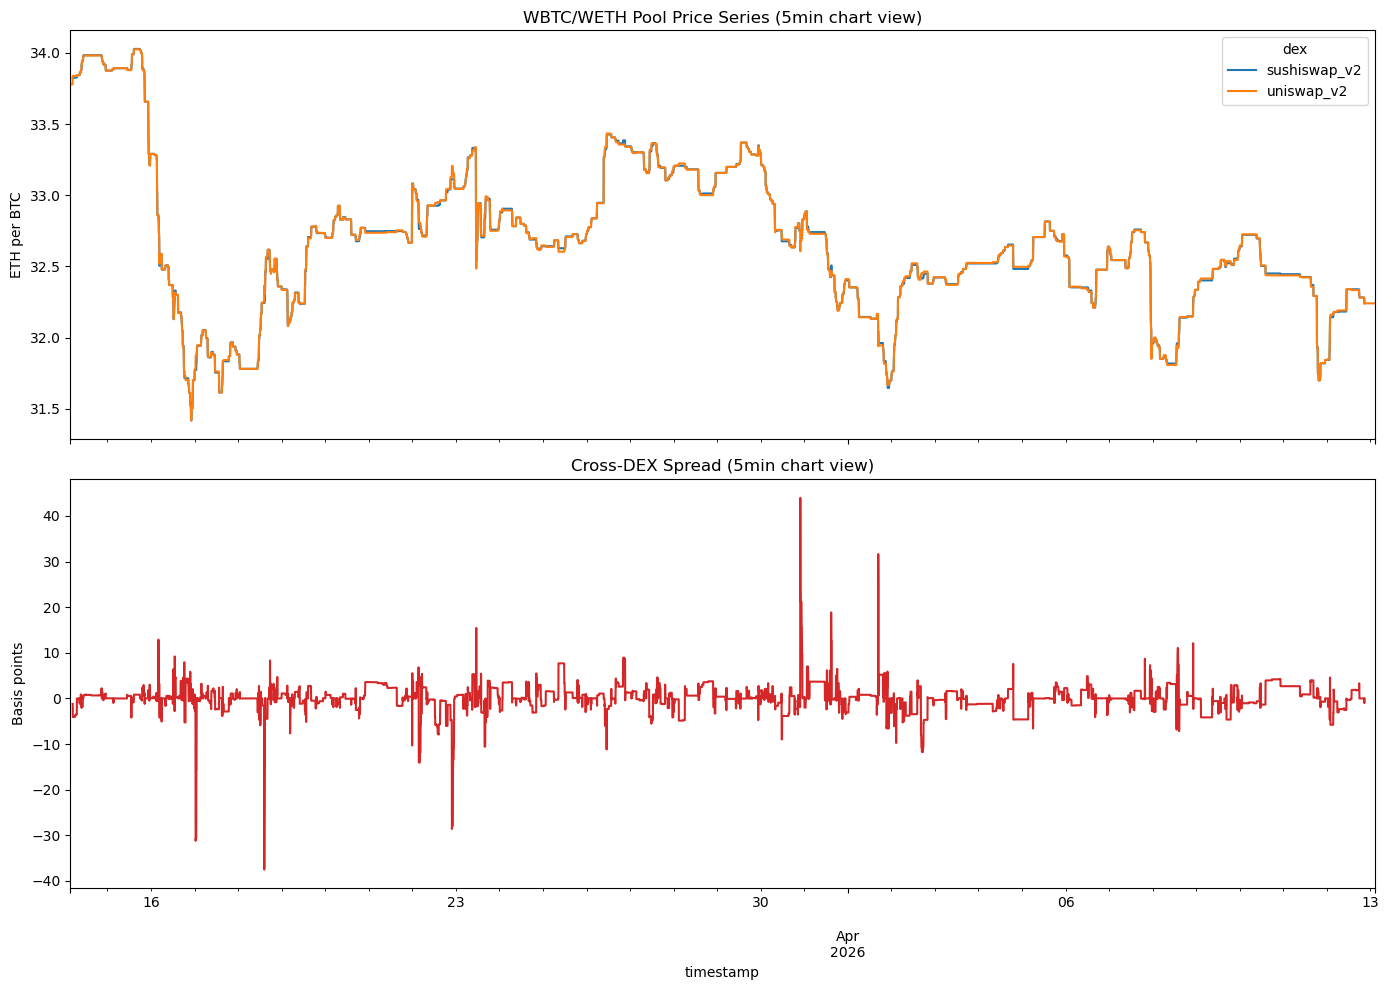

In [7]:
pool_state_with_split = pool_state_with_split.copy()
arb_with_split = arb_with_split.copy()
pool_state_with_split['timestamp'] = pd.to_datetime(pool_state_with_split['timestamp'], utc=True)
arb_with_split['timestamp'] = pd.to_datetime(arb_with_split['timestamp'], utc=True)

plot_pool_state = (
    pool_state_with_split.groupby(['dex', pd.Grouper(key='timestamp', freq=PLOT_FREQUENCY)], as_index=False)
    .last()
)
price_pivot = plot_pool_state.pivot(index='timestamp', columns='dex', values='mid_price_eth_per_btc')
spread_bps = (price_pivot.iloc[:, 0] / price_pivot.iloc[:, 1] - 1.0) * 10_000.0

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
price_pivot.plot(ax=axes[0], title=f'WBTC/WETH Pool Price Series ({PLOT_FREQUENCY} chart view)')
axes[0].set_ylabel('ETH per BTC')
spread_bps.plot(ax=axes[1], color='tab:red', title=f'Cross-DEX Spread ({PLOT_FREQUENCY} chart view)')
axes[1].set_ylabel('Basis points')
plt.tight_layout()
plt.show()

In [8]:
price_summary = (
    pool_state_with_split.groupby('dex', as_index=False)
    .agg(
        mean_price_eth_per_btc=('mid_price_eth_per_btc', 'mean'),
        std_price_eth_per_btc=('mid_price_eth_per_btc', 'std'),
        min_price_eth_per_btc=('mid_price_eth_per_btc', 'min'),
        max_price_eth_per_btc=('mid_price_eth_per_btc', 'max'),
    )
)
swap_activity = (
    pool_state_with_split.assign(hour_utc=pool_state_with_split['timestamp'].dt.hour)
    .groupby(['dex', 'hour_utc'], as_index=False)
    .agg(
        avg_swap_count=('swap_count', 'mean'),
        avg_volume_wbtc=('volume_wbtc', 'mean'),
        avg_volume_weth=('volume_weth', 'mean'),
    )
)
liquidity_summary = (
    pool_state_with_split.groupby('dex', as_index=False)
    .agg(
        mean_reserve_wbtc=('reserve_wbtc', 'mean'),
        median_reserve_wbtc=('reserve_wbtc', 'median'),
        mean_reserve_weth=('reserve_weth', 'mean'),
        median_reserve_weth=('reserve_weth', 'median'),
    )
)
split_descriptives = (
    arb_with_split.groupby('split', as_index=False)
    .agg(
        mean_net_edge_bps=('net_edge_bps', 'mean'),
        median_net_edge_bps=('net_edge_bps', 'median'),
        positive_opportunities=('opportunity_flag', 'sum'),
        observations=('timestamp', 'count'),
    )
)

display(price_summary)
display(liquidity_summary)
display(swap_activity.head(24))
display(split_descriptives)

,dex,mean_price_eth_per_btc,std_price_eth_per_btc,min_price_eth_per_btc,max_price_eth_per_btc
0,sushiswap_v2,32.669937,0.504043,31.418358,34.027719
1,uniswap_v2,32.668224,0.505081,31.420155,34.024893


,dex,mean_reserve_wbtc,median_reserve_wbtc,mean_reserve_weth,median_reserve_weth
0,sushiswap_v2,15.983164,15.987444,522.10665,522.011005
1,uniswap_v2,57.860419,57.877677,1889.97295,1889.316364


,dex,hour_utc,avg_swap_count,avg_volume_wbtc,avg_volume_weth
0,sushiswap_v2,0,0.000776,2.115882e-06,0.000069
1,sushiswap_v2,1,0.000738,2.664066e-06,0.000086
2,sushiswap_v2,2,0.000421,1.648565e-06,0.000054
3,sushiswap_v2,3,0.000584,3.014320e-06,0.000098
4,sushiswap_v2,4,0.000563,1.916938e-06,0.000062
5,sushiswap_v2,5,0.000593,1.553099e-06,0.000051
6,sushiswap_v2,6,0.000574,1.585141e-06,0.000052
7,sushiswap_v2,7,0.000463,2.012469e-06,0.000066
8,sushiswap_v2,8,0.000213,8.781563e-07,0.000029
9,sushiswap_v2,9,0.000519,2.043639e-06,0.000067


,split,mean_net_edge_bps,median_net_edge_bps,positive_opportunities,observations
0,test,-137.907822,-138.582788,0,384421
1,train,-138.670626,-139.202618,0,1793963
2,validation,-138.697003,-139.153339,0,384421


## 4. Fit The Opportunity Model

The binary opportunity flag is still sparse even at second resolution, so the notebook fits the transparent regression/ranking model and then surfaces the highest-scoring seconds and the contiguous positive windows.

In [9]:
model_frame = build_opportunity_model_frame(pool_state_with_split, arb_with_split)
model = fit_opportunity_model(model_frame)
scores = score_opportunity_model(model_frame, model)
metrics = summarize_model_scores(scores)
top_candidates = top_opportunity_candidates(scores, limit=20)
coefficient_table = pd.DataFrame(
    {
        'feature': list(model.feature_columns),
        'coefficient': list(model.coefficients),
    }
)

positive_seconds = scores[scores['opportunity_flag']].copy().sort_values('timestamp')
if positive_seconds.empty:
    opportunity_windows = pd.DataFrame(
        columns=['start_timestamp', 'end_timestamp', 'seconds', 'buy_dex', 'sell_dex', 'max_net_edge_bps', 'mean_net_edge_bps']
    )
else:
    positive_seconds['new_window'] = (
        positive_seconds['timestamp'].diff().ne(pd.Timedelta(seconds=1))
        | positive_seconds['buy_dex'].ne(positive_seconds['buy_dex'].shift())
        | positive_seconds['sell_dex'].ne(positive_seconds['sell_dex'].shift())
    )
    positive_seconds['window_id'] = positive_seconds['new_window'].cumsum()
    opportunity_windows = (
        positive_seconds.groupby('window_id', as_index=False)
        .agg(
            start_timestamp=('timestamp', 'min'),
            end_timestamp=('timestamp', 'max'),
            seconds=('timestamp', 'count'),
            buy_dex=('buy_dex', 'first'),
            sell_dex=('sell_dex', 'first'),
            max_net_edge_bps=('net_edge_bps', 'max'),
            mean_net_edge_bps=('net_edge_bps', 'mean'),
        )
        .sort_values(['max_net_edge_bps', 'seconds'], ascending=[False, False])
        .reset_index(drop=True)
    )

if WRITE_OUTPUTS:
    _write_curated_table(curated_dir, score_stem, scores)
    metrics.to_csv(metrics_path, index=False)
    top_candidates.to_csv(candidate_path, index=False)
    opportunity_windows.to_csv(window_path, index=False)
    save_opportunity_model(model, model_path)

display(coefficient_table)
display(metrics)
display(top_candidates)
display(opportunity_windows.head(20))

,feature,coefficient
0,abs_spread_bps,0.992410
1,abs_spread_sq,0.000022
2,base_fee_gwei,-0.631454


,split,observations,actual_positive_count,predicted_positive_count,rmse_bps,mae_bps,correlation,top_10_best_realized_net_edge_bps,top_10_positive_hits
0,train,1793963,0,0,0.660878,0.521430,0.968111,-93.434759,0
1,validation,384421,0,0,0.472716,0.354317,0.973461,-97.562269,0
2,test,384421,0,0,0.604640,0.499737,0.973499,-124.598130,0
3,all,2562805,0,0,0.627765,0.493109,0.966283,-93.434759,0


,timestamp,split,candidate_buy_dex,candidate_sell_dex,price_spread_bps,abs_spread_bps,base_fee_gwei,predicted_net_edge_bps,predicted_opportunity_flag,net_edge_bps,opportunity_flag
0,2026-03-23 11:11:35+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
1,2026-03-23 11:11:36+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
2,2026-03-23 11:11:37+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
3,2026-03-23 11:11:38+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
4,2026-03-23 11:11:39+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
5,2026-03-23 11:11:40+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
6,2026-03-23 11:11:41+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
7,2026-03-23 11:11:42+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
8,2026-03-23 11:11:43+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False
9,2026-03-23 11:11:44+00:00,train,uniswap_v2,sushiswap_v2,47.409049,47.409049,0.096715,-93.236187,False,-93.434759,False


,start_timestamp,end_timestamp,seconds,buy_dex,sell_dex,max_net_edge_bps,mean_net_edge_bps


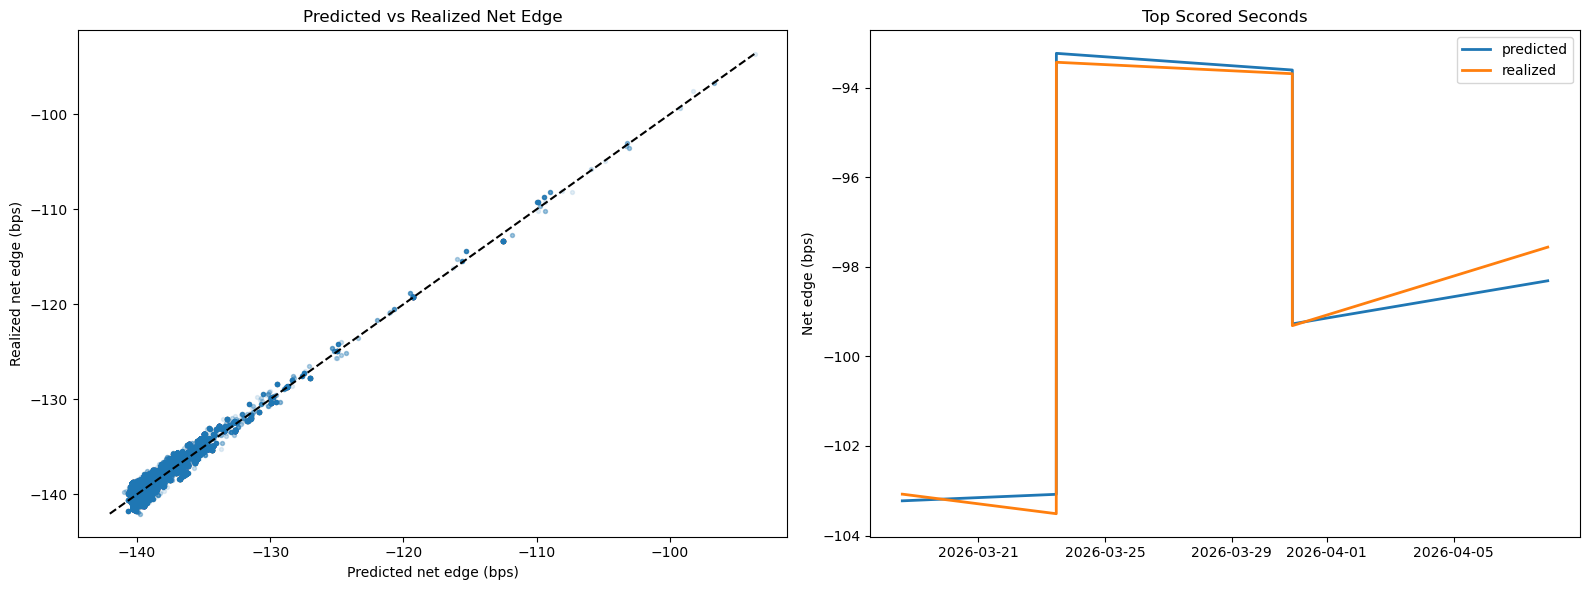

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_scores = scores.sample(n=min(100000, len(scores)), random_state=42)
axes[0].scatter(sample_scores['predicted_net_edge_bps'], sample_scores['net_edge_bps'], alpha=0.12, s=8)
line_min = min(sample_scores['predicted_net_edge_bps'].min(), sample_scores['net_edge_bps'].min())
line_max = max(sample_scores['predicted_net_edge_bps'].max(), sample_scores['net_edge_bps'].max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle='--', color='black')
axes[0].set_title('Predicted vs Realized Net Edge')
axes[0].set_xlabel('Predicted net edge (bps)')
axes[0].set_ylabel('Realized net edge (bps)')

if not opportunity_windows.empty:
    best_window = opportunity_windows.iloc[0]
    mask = (scores['timestamp'] >= best_window['start_timestamp']) & (scores['timestamp'] <= best_window['end_timestamp'])
    window_scores = scores.loc[mask].sort_values('timestamp')
    axes[1].plot(window_scores['timestamp'], window_scores['predicted_net_edge_bps'], label='predicted', linewidth=2)
    axes[1].plot(window_scores['timestamp'], window_scores['net_edge_bps'], label='realized', linewidth=2)
    axes[1].set_title('Best Positive Window')
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].legend()
else:
    top_window = scores.nlargest(min(200, len(scores)), 'predicted_net_edge_bps').sort_values('timestamp')
    axes[1].plot(top_window['timestamp'], top_window['predicted_net_edge_bps'], label='predicted', linewidth=2)
    axes[1].plot(top_window['timestamp'], top_window['net_edge_bps'], label='realized', linewidth=2)
    axes[1].set_title('Top Scored Seconds')
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Optional Files Written By This Notebook

In [11]:
written_files = [
    raw_dir / 'event_logs.parquet',
    raw_dir / 'event_logs_preview.csv',
    raw_dir / 'block_headers.parquet',
    raw_dir / 'block_headers_preview.csv',
    raw_dir / 'pair_metadata.parquet',
    raw_dir / 'pair_metadata_preview.csv',
    curated_dir / f'{pool_state_stem}.parquet',
    curated_dir / f'{pool_state_stem}_preview.csv',
    curated_dir / f'{arb_label_stem}.parquet',
    curated_dir / f'{arb_label_stem}_preview.csv',
    curated_dir / f'{score_stem}.parquet',
    curated_dir / f'{score_stem}_preview.csv',
    split_assignments_parquet,
    split_assignments_preview,
    metrics_path,
    candidate_path,
    window_path,
    model_path,
]

file_table = pd.DataFrame(
    {
        'file': [str(path.relative_to(PROJECT_ROOT)) for path in written_files],
        'exists': [path.exists() for path in written_files],
    }
)
display(file_table)
display(Markdown(
    'Notebook complete. The regenerated artifacts have been written to disk in parquet plus preview CSV format.'
))

,file,exists
0,data/raw/event_logs.parquet,True
1,data/raw/event_logs_preview.csv,True
2,data/raw/block_headers.parquet,True
3,data/raw/block_headers_preview.csv,True
4,data/raw/pair_metadata.parquet,True
5,data/raw/pair_metadata_preview.csv,True
6,data/curated/pool_state_1s.parquet,True
7,data/curated/pool_state_1s_preview.csv,True
8,data/curated/arb_labels_1s.parquet,True
9,data/curated/arb_labels_1s_preview.csv,True


Notebook complete. The regenerated artifacts have been written to disk in parquet plus preview CSV format.